In [2]:
import pandas
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


import stpsf
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import astropy, astropy.io.fits as fits



# Match PSF to file

In [ ]:
# set stspfs path
stpsf_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/stpsf-data'


In [3]:
filename = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MAST_2026-02-18T1439/JWST/jw06565-o002_t001_nircam_clear-f200w/jw06565-o002_t001_nircam_clear-f200w_i2d.fits'
inst = stpsf.setup_sim_to_match_file(filename)

Setting up sim to match /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MAST_2026-02-18T1439/JWST/jw06565-o002_t001_nircam_clear-f200w/jw06565-o002_t001_nircam_clear-f200w_i2d.fits

MAST OPD query around UTC: 2024-06-04T14:48:30.506
                        MJD: 60465.61701974537

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/R2024060302-NRCA3_FP1-1.fits
	Date (MJD):	 60464.1568
	Delta time:	 -1.4602 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2024060501-NRCA3_FP1-1.fits
	Date (MJD):	 60466.1059
	Delta time:	 0.4889 days
User requested choosing OPD time closest in time to 2024-06-04T14:48:30.506, which is O2024060501-NRCA3_FP1-1.fits, delta time 0.489 days
Importing and format-converting OPD from /Users/mncavieres/data/stpsf-data/MAST_JWST_WSS_OPDs/O2024060501-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)
Sensing inst model using apername NRCA3_FP1
Using sensing fi

In [ ]:

import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.nddata import NDData
from photutils.detection import DAOStarFinder
from photutils.psf import extract_stars, EPSFBuilder
from photutils.background import Background2D, MedianBackground

def build_epsf(image2d, fwhm_guess_pix, cutout_size=101, max_stars=50,
               threshold_sigma=7.0, bkg_box=128, bkg_filter=3):
    img = np.array(image2d, dtype=float)
    print('Image loaded. Building ePSF...')

    # 1) mask non-finite pixels (very common in i2d)
    mask = ~np.isfinite(img)
    if np.all(mask):
        raise ValueError("Image is all non-finite.")
    print(f"Masked {mask.sum()} non-finite pixels.")

    # 2) subtract smooth background (important for galaxy fields)
    print("Estimating background with Background2D...")
    # If your image is huge, Background2D can be a bit slow but worth it.
    bkg = Background2D(img, box_size=bkg_box, filter_size=bkg_filter,
                       bkg_estimator=MedianBackground(), mask=mask)
    img_sub = img - bkg.background
    print("Background subtracted.")
    # 3) robust stats on background-subtracted image
    mean, med, std = sigma_clipped_stats(img_sub, sigma=3.0, mask=mask)
    
    print(f"Background stats: mean={mean:.2f}, median={med:.2f}, std={std:.2f}")
    print(f"Using FWHM guess of {fwhm_guess_pix} pixels and threshold of {threshold_sigma} sigma.")
    daofind = DAOStarFinder(fwhm=fwhm_guess_pix, threshold=threshold_sigma * std,
                            exclude_border=True)
    print("Running DAOStarFinder...")

    tbl = daofind(img_sub - med)
    if tbl is None or len(tbl) == 0:
        raise RuntimeError(
            f"No stars found. Try lowering threshold_sigma (currently {threshold_sigma}) "
            f"or adjusting fwhm_guess_pix (currently {fwhm_guess_pix})."
        )

    # brightest first
    tbl.sort('flux')
    tbl.reverse()
    tbl = tbl[:max_stars]

    nd = NDData(data=img_sub - med, mask=mask)
    stars = extract_stars(nd, tbl, size=cutout_size)

    # drop any star cutouts with NaNs (happens near mosaic edges / gaps)
    stars = stars[np.array([np.isfinite(s.data).all() for s in stars])]

    if len(stars) < 5:
        raise RuntimeError(f"Too few usable stars after filtering: {len(stars)}")

    epsf_builder = EPSFBuilder(oversampling=1, maxiters=7, progress_bar=True)
    epsf, fitted_stars = epsf_builder(stars)

    psf = epsf.data.astype(float)
    psf[~np.isfinite(psf)] = 0.0
    psf /= psf.sum()
    return psf

# set paths to mosaics
f090 = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MAST_2026-02-18T0947/JWST/jw06565-o002_t001_nircam_clear-f090w/jw06565-o002_t001_nircam_clear-f090w_i2d.fits'
f200 = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MAST_2026-02-18T1439/JWST/jw06565-o002_t001_nircam_clear-f200w/jw06565-o002_t001_nircam_clear-f200w_i2d.fits'

# load mosaics
with fits.open(f090) as h0:
    img090 = h0[1].data
with fits.open(f200) as h1:
    img200 = h1[1].data

# crude FWHM guesses: F200W should be broader than F090W
psf090 = build_epsf(img090, fwhm_guess_pix=1.1, cutout_size=101)
psf200 = build_epsf(img200, fwhm_guess_pix=1.2, cutout_size=101)


Image loaded. Building ePSF...
Masked 3380283 non-finite pixels.
Estimating background with Background2D...
Background subtracted.
Background stats: mean=0.02, median=0.00, std=0.16
Using FWHM guess of 2.0 pixels and threshold of 7.0 sigma.
Running DAOStarFinder...


ValueError: When inputting multiple catalogs, each one must have a "x" and "y" column or a "skycoord" column.

# Make a detection image that removes the galaxy

In [8]:
import numpy as np
from scipy.ndimage import gaussian_filter

def make_detection_image(img, sigma_pix=15):
    img = np.array(img, dtype=float)
    med = np.nanmedian(img)
    smooth = gaussian_filter(np.nan_to_num(img, nan=med), sigma=sigma_pix)
    det = img - smooth
    det[~np.isfinite(det)] = 0.0
    return det

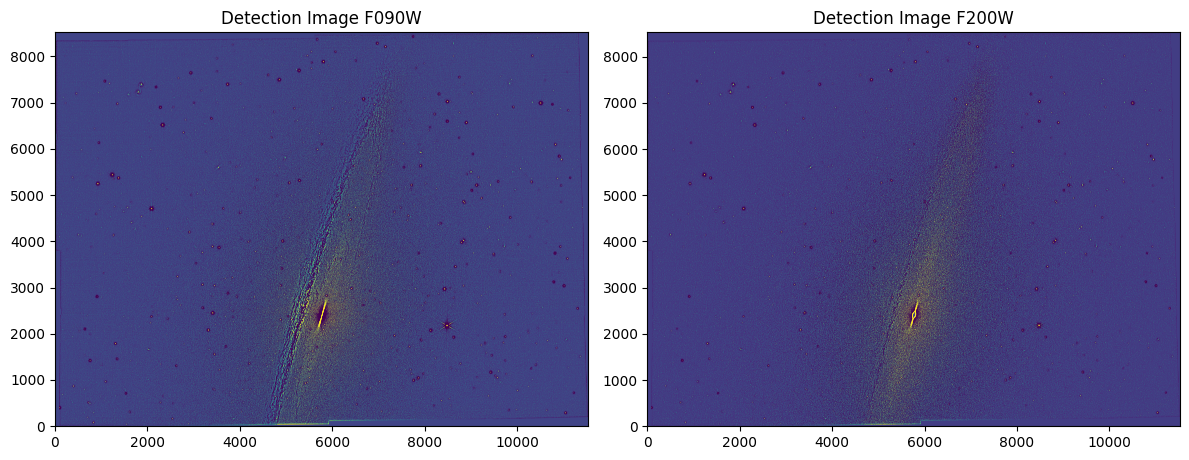

In [9]:
det_f090 = make_detection_image(img090)
det_f200 = make_detection_image(img200)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes[0].imshow(det_f090, origin='lower', cmap='viridis',
                      vmin=np.nanpercentile(det_f090, 5), vmax=np.nanpercentile(det_f090, 99.5))
im1 = axes[1].imshow(det_f200, origin='lower', cmap='viridis',
                      vmin=np.nanpercentile(det_f200, 5), vmax=np.nanpercentile(det_f200, 99.5))
axes[0].set_title('Detection Image F090W')
axes[1].set_title('Detection Image F200W')
#fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
#fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [ ]:
def background_subtract(image2d, bkg_box=128, bkg_filter=3):
    img = np.array(image2d, dtype=float)
    mask = ~np.isfinite(img)
    if np.all(mask):
        raise ValueError("Image is all non-finite.")
    print(f"Masked {mask.sum()} non-finite pixels.")

    print("Estimating background with Background2D...")
    bkg = Background2D(img, box_size=bkg_box, filter_size=bkg_filter,
                       bkg_estimator=MedianBackground(), mask=mask)
    img_sub = img - bkg.background
    print("Background subtracted.")
    return img_sub

# Make a matching kernel


In [ ]:
from photutils.psf.matching import create_matching_kernel, CosineBellWindow

# ensure same shape (crop/pad if needed; here we assume both are same cutout_size)
window = CosineBellWindow(alpha=0.35)
kernel_090_to_200 = create_matching_kernel(psf090, psf200, window=window)


# Convolve F090W down to F200W PSF

In [ ]:
from astropy.convolution import convolve_fft

img090_matched = convolve_fft(
    img090, kernel_090_to_200,
    normalize_kernel=False,
    boundary="fill", fill_value=0.0,
    allow_huge=True
)


# Compare the PSFs

In [ ]:
psf090_conv = convolve_fft(psf090, kernel_090_to_200, normalize_kernel=False)
# compare psf090_conv vs psf200 (radial profiles / FWHM / encircled energy)
